# 00 — Explorando o Dataset (Find it again!)

Vamos carregar o dataset usando a nossa implementação oficial `dataset_loader.py` para visualizar uma amostra aleatória de documentos autênticos e adulterados.

O objetivo aqui é puramente visual: avaliar quão evidentes são as alterações e como nossas anotações (bounding boxes) são projetadas na imagem real.


In [3]:
import sys
sys.path.append("../src")

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from matplotlib.patches import Rectangle
from dataset_loader import load_dataset

DATASET_ROOT = "../data/findit2"
samples = load_dataset(DATASET_ROOT, "test")

print(f"Total de amostras carregadas: {len(samples)}")


Total de amostras carregadas: 218


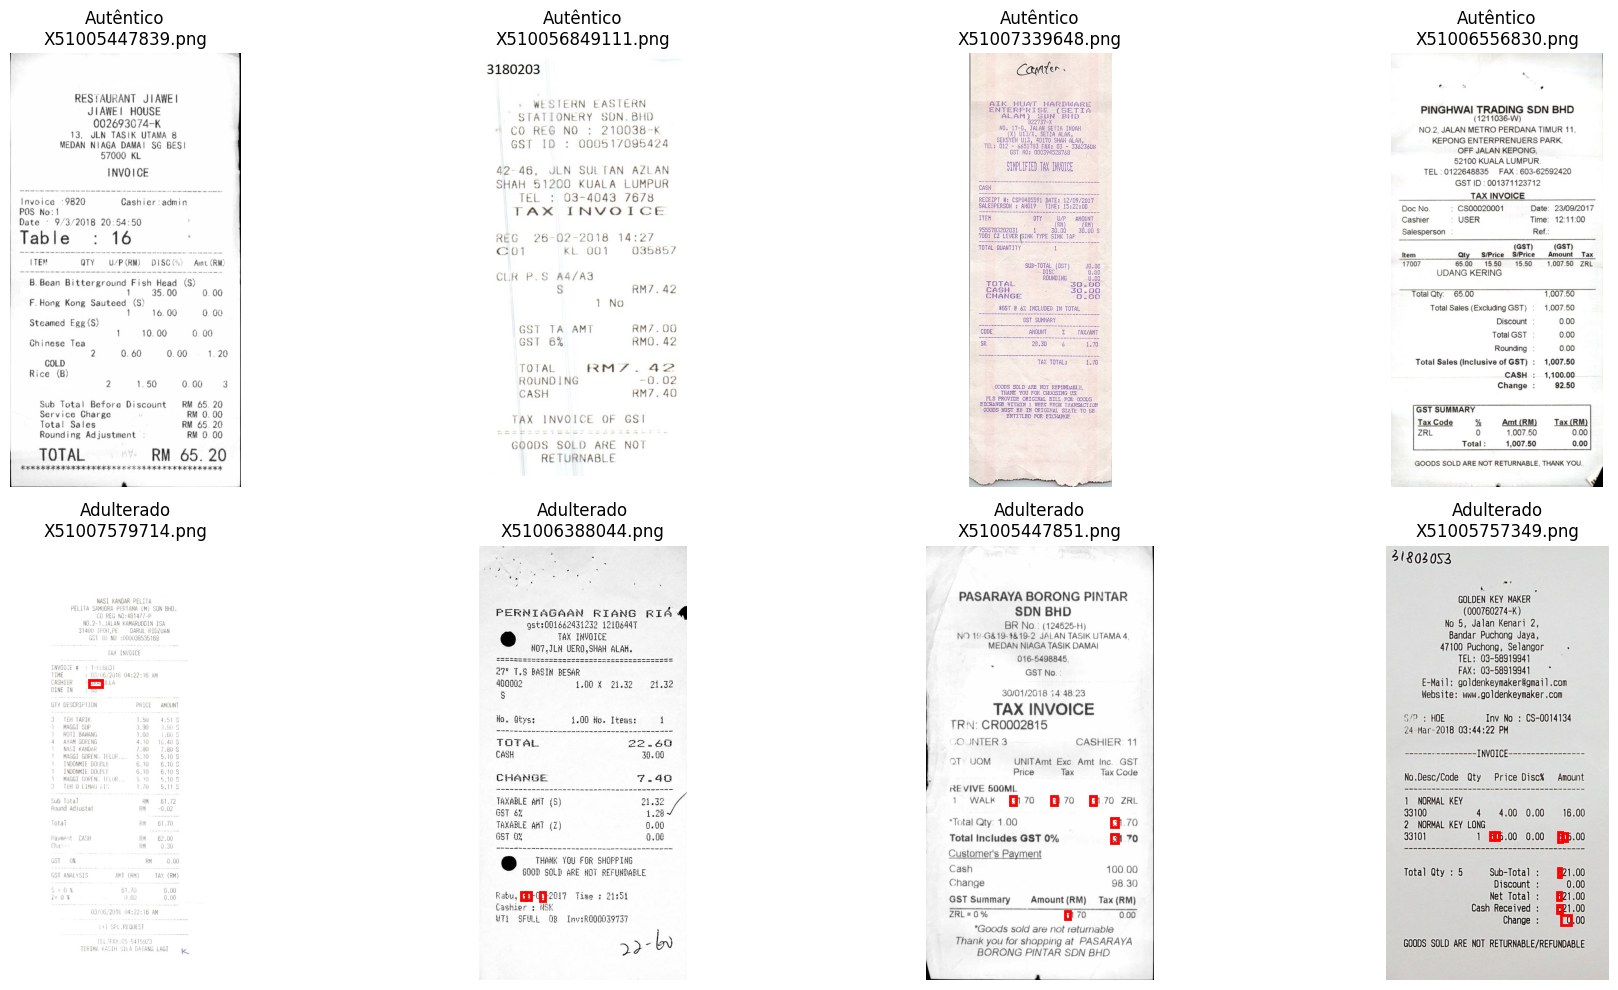

In [4]:
# Selecionar amostra aleatória
np.random.seed(42)

auth_samples = [s for s in samples if not s.is_tampered]
forg_samples = [s for s in samples if s.is_tampered]

auth_choice = np.random.choice(auth_samples, size=4, replace=False)
forg_choice = np.random.choice(forg_samples, size=4, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Linha 1: Autênticos
for ax, s in zip(axes[0], auth_choice):
    img = Image.open(s.image_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"Autêntico\n{s.image_path.name}")
    ax.axis("off")

# Linha 2: Adulterados
for ax, s in zip(axes[1], forg_choice):
    img = Image.open(s.image_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"Adulterado\n{s.image_path.name}")
    ax.axis("off")
    
    # Desenhar as regiões
    for r in s.regions:
        if getattr(r, 'is_original_area', None) is True:
            continue # Não desenhamos a fonte do copy-paste, apenas o destino
            
        x, y, w, h = r.bbox
        ax.add_patch(Rectangle(
            (x, y), w, h, fill=False,
            edgecolor="red",
            linewidth=2,
            linestyle="-"
        ))

plt.tight_layout()
plt.show()


## Observações Visuais

1. **A olho nu, as adulterações são extremamente sutis**. Muitas vezes são apenas dígitos de um preço ou pequenos textos alterados usando a mesma fonte e cor, ou seja, quase impossíveis de serem detectados sem auxílio computacional.
2. **As bounding boxes marcam corretamente os limites do local adulterado**, e como as edições são finas (focadas apenas nos pixels de texto alvo), qualquer técnica de detecção vai precisar ter precisão espacial suficiente para não ser ofuscada pelas áreas não adulteradas vizinhas.
